In [125]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score

In [126]:
df = pd.read_csv('cardio_train.csv', sep=';')

In [127]:
df["age_years"] = df["age"] // 365

In [128]:
df["BMI"] = df["weight"] / ((df["height"] / 100) ** 2)

In [129]:
df = df.drop("age", axis=1)

In [130]:
df = df.drop("id", axis=1)

In [131]:
df.head()

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,BMI
0,2,168,62.0,110,80,1,1,0,0,1,0,50,21.967120
1,1,156,85.0,140,90,3,1,0,0,1,1,55,34.927679
2,1,165,64.0,130,70,3,1,0,0,0,1,51,23.507805
3,2,169,82.0,150,100,1,1,0,0,1,1,48,28.710479
4,1,156,56.0,100,60,1,1,0,0,0,0,47,23.011177


In [132]:
df.isnull().sum()

gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
age_years      0
BMI            0
dtype: int64

In [133]:
df["cardio"].value_counts()

0    35021
1    34979
Name: cardio, dtype: int64

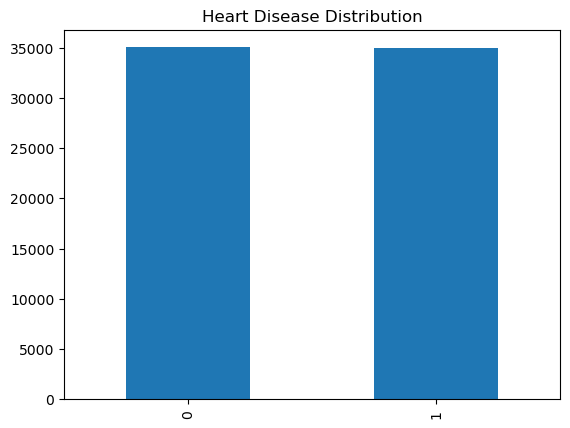

In [134]:


df["cardio"].value_counts().plot(kind="bar")
plt.title("Heart Disease Distribution")
plt.show()

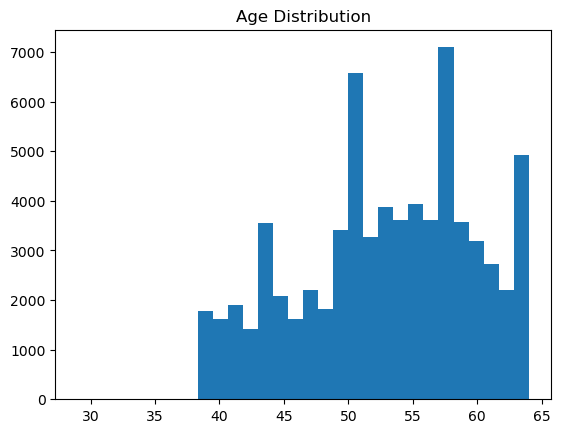

In [135]:
plt.hist(df["age_years"], bins=30)
plt.title("Age Distribution")
plt.show()

In [136]:
X = df.drop("cardio", axis=1)
y = df["cardio"]

In [137]:
print(X.shape)
print(y.shape)

(70000, 12)
(70000,)


In [138]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [139]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [140]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [141]:
y_pred = model.predict(X_test_scaled)

y_prob = model.predict_proba(X_test_scaled)[:,1]

In [142]:
accuracy_score(y_test, y_pred)

0.7140714285714286

In [143]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.70      0.75      0.72      7004
           1       0.73      0.68      0.70      6996

    accuracy                           0.71     14000
   macro avg       0.72      0.71      0.71     14000
weighted avg       0.72      0.71      0.71     14000



In [144]:
roc_auc_score(y_test,y_pred)

0.7140494168324627

In [145]:
X_test.sample(5)

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,age_years,BMI
40475,2,170,71.0,120,80,1,1,0,0,1,49,24.567474
62573,2,174,69.0,110,70,2,1,0,0,1,45,22.790329
26249,2,168,87.0,120,80,1,1,0,0,0,63,30.824830
32196,2,175,67.0,130,80,1,1,0,0,0,50,21.877551
64845,1,168,68.0,110,70,1,1,0,0,1,54,24.092971


In [146]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("features.pkl", "wb") as f:
    pickle.dump(list(X.columns), f)